In [5]:
import pandas as pd
import numpy as np
from sklearn.datasets import fetch_california_housing
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.model_selection import train_test_split, KFold
# from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error, r2_score
import matplotlib.pyplot as plt
from math import sqrt
np.random.seed(42)

#### Getting the data

In [6]:
# Load the california housing dataset
cali_data = fetch_california_housing(as_frame=True)

In [7]:
X = cali_data.data
y = cali_data.target * 100_000  # scale target to actual house price in USD

print(f"Dataset shape: {X.shape}")
X.head()

Dataset shape: (20640, 8)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [8]:
y[:5]

0    452600.0
1    358500.0
2    352100.0
3    341300.0
4    342200.0
Name: MedHouseVal, dtype: float64

#### Splitting the data

In [10]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Train shape: {X_train.shape} Test shape: {X_test.shape}")

Train shape: (16512, 8) Test shape: (4128, 8)


#### Linear regression

In [11]:
lr = LinearRegression() # define the model
lr.fit(X_train, y_train) # training the model
y_pred_lr = lr.predict(X_test) # performance evaluation on test data

In [12]:
y_test[:5].tolist() # actual first 5 prices

[47700.0, 45800.0, 500000.99999999994, 218600.0, 278000.0]

In [13]:
y_pred_lr[:5].tolist() # predicted first 5 prices

[71912.28416019166,
 176401.6570662423,
 270965.88334317226,
 283892.59301839536,
 260465.72518102964]

In [14]:
rmse = sqrt(mean_squared_error(y_test, y_pred_lr))
rmse

74558.13830127762

In [15]:
# function that returns performance evaluation metrics
def regression_metrics(y_true, y_pred):
    mae = round(mean_absolute_error(y_true, y_pred), 2)
    mse = round(mean_squared_error(y_true, y_pred), 2)
    rmse = round(sqrt(mse), 2)
    mape = round(mean_absolute_percentage_error(y_true, y_pred), 2)
    r2 = round(r2_score(y_true, y_pred), 2)
    return {"MAE": mae, "MSE": mse, "RMSE": rmse, "MAPE": mape, "R2": r2}

In [16]:
# Linear regression evaluation
metrics_lr = regression_metrics(y_test, y_pred_lr)
metrics_lr

{'MAE': 53320.01,
 'MSE': 5558915986.95,
 'RMSE': 74558.14,
 'MAPE': 0.32,
 'R2': 0.58}

In [17]:
# coefficients for the different features
coef_df = pd.DataFrame({
    "feature": X.columns,
    "coefficient": lr.coef_
}).sort_values(by="coefficient", key=lambda s: s.abs(), ascending=False)
coef_df

,feature,coefficient
3,AveBedrms,78314.490679
0,MedInc,44867.490967
7,Longitude,-43370.806496
6,Latitude,-41979.248659
2,AveRooms,-12332.334283
1,HouseAge,972.425752
5,AveOccup,-352.631849
4,Population,-0.202962


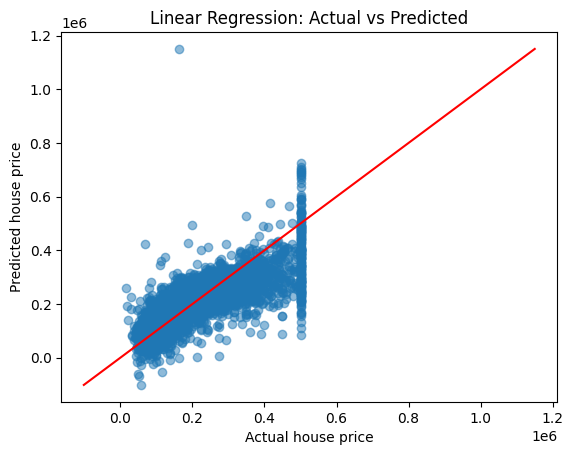

In [18]:
# visualization of predicted vs actual house prices
plt.scatter(y_test, y_pred_lr, alpha=0.5)
plt.xlabel("Actual house price")
plt.ylabel("Predicted house price")
plt.title("Linear Regression: Actual vs Predicted")
lims = [min(y_test.min(), y_pred_lr.min()), max(y_test.max(), y_pred_lr.max())]
plt.plot(lims, lims, "r")
plt.show()

#### Regularization

In [19]:
# Ridge and Lasso regression
ridge = Ridge(alpha=1.0)
lasso = Lasso(alpha=1.0)

# training
ridge.fit(X_train, y_train)
lasso.fit(X_train, y_train)

# making predictions for test data
y_pred_ridge = ridge.predict(X_test)
y_pred_lasso = lasso.predict(X_test)

# performance evaluation
metrics_ridge = regression_metrics(y_test, y_pred_ridge)
metrics_lasso = regression_metrics(y_test, y_pred_lasso)

# creating dataframe from a list of performance metrics dictionaries
pd.DataFrame([metrics_lr, metrics_ridge, metrics_lasso],
             index=["Linear", "Ridge α=1", "Lasso α=1"])

,MAE,MSE,RMSE,MAPE,R2
Linear,53320.01,5.558916e+09,74558.14,0.32,0.58
Ridge α=1,53320.39,5.558035e+09,74552.23,0.32,0.58
Lasso α=1,53320.07,5.558707e+09,74556.74,0.32,0.58


In [20]:
# coefficient comparison
coef_comp = pd.DataFrame({
    "feature": X.columns,
    "Linear": lr.coef_,
    "Ridge": ridge.coef_,
    "Lasso": lasso.coef_
}).set_index("feature")
coef_comp

,Linear,Ridge,Lasso
feature,,,
MedInc,44867.490967,44851.092430,44863.514558
HouseAge,972.425752,972.596535,972.484218
AveRooms,-12332.334283,-12301.415662,-12324.748486
AveBedrms,78314.490679,78141.676063,78272.519515
Population,-0.202962,-0.202581,-0.202790
AveOccup,-352.631849,-352.585878,-352.615173
Latitude,-41979.248659,-41978.690849,-41977.977288
Longitude,-43370.806496,-43368.079268,-43368.925999


---
## Cross-Validation

A single train/test split can be noisy. You might get lucky or unlucky. K-Fold CV solves this by:

1. Splitting data into K equal folds (commonly K=5 or K=10)
2. Training on K-1 folds, validating on the remaining 1
3. Repeating K times, each time with a different validation fold
4. Averaging the K scores = more reliable performance estimate

In [21]:
k = 5  # number of folds
kf = KFold(n_splits=k, shuffle=True, random_state=42)

rmse_scores = []
r2_scores = []
mae_scores = []
mape_scores = []

fold = 1
for train_index, test_index in kf.split(X):
    print(f"\n--- Fold {fold} ---")

    # Split data manually using indices
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    # Initialize your model
    model = LinearRegression()

    # Train and make predictions
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    # Compute metrics
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    mape = mean_absolute_percentage_error(y_test, y_pred)

    # Save results
    rmse_scores.append(rmse)
    r2_scores.append(r2)
    mae_scores.append(mae)
    mape_scores.append(mape)

    print(f"RMSE: {rmse:.2f}")
    print(f"R² Score: {r2:.2f}")
    print(f"MAE Score: {mae:.2f}")
    print(f"MAPE Score: {mape:.2f}")

    fold += 1


--- Fold 1 ---
RMSE: 74558.14
R² Score: 0.58
MAE Score: 53320.01
MAPE Score: 0.32

--- Fold 2 ---
RMSE: 72639.95
R² Score: 0.61
MAE Score: 53667.97
MAPE Score: 0.32

--- Fold 3 ---
RMSE: 71364.08
R² Score: 0.61
MAE Score: 52917.63
MAPE Score: 0.32

--- Fold 4 ---
RMSE: 71052.85
R² Score: 0.62
MAE Score: 51713.83
MAPE Score: 0.31

--- Fold 5 ---
RMSE: 74510.43
R² Score: 0.59
MAE Score: 54218.98
MAPE Score: 0.32


In [18]:
print(f"Average RMSE: {np.mean(rmse_scores):.2f}")
print(f"Average R² Score: {np.mean(r2_scores):.2f}")
print(f"Average MAE: {np.mean(mae_scores):.2f}")
print(f"Average MAPE: {np.mean(mape_scores):.2f}")

Average RMSE: 72825.09
Average R² Score: 0.60
Average MAE: 53167.68
Average MAPE: 0.32


**Exercise**
1. Standardize the data first and then fit the models. How does this affect the results?
2.  Change the value of `alpha` in the Ridge and Lasso models (for example: `0.01`, `0.1`, `1`, `10`). How does the performance change as `alpha` increases? Show this visually.
3.  Generate polynomial features of degree 2. Fit a Linear Regression model using the transformed dataset. Compare the performance metrics (MAE, RMSE, MAPE, R²) with the original linear regression model.
4.  Use `RepeatedFold` instead of `KFold`. Compare the performance.

In [3]:
import pandas as pd
import numpy as np
import plotly.express as px
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [22]:
# 1. Standardize the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Models to test
models = {
    "Linear": LinearRegression(),
    "Ridge (alpha = 1)": Ridge(alpha=1),
    "Lasso (alpha = 0.1)": Lasso(alpha=0.1)
}

results = []
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    preds = model.predict(X_test_scaled)
    
    results.append({
        "Model": name,
        "MAE": mean_absolute_error(y_test, preds),
        "RMSE": np.sqrt(mean_squared_error(y_test, preds)),
        "MAPE": mean_absolute_percentage_error(y_test,preds),
        "R2": r2_score(y_test, preds)
    })

# Professional performance summary
df_results = pd.DataFrame(results)
print("Performance with Standardized Data:")
display(df_results)

Performance with Standardized Data:


,Model,MAE,RMSE,MAPE,R2
0,Linear,54218.978060,74510.434035,0.319600,0.587529
1,Ridge (alpha = 1),54218.055907,74510.445994,0.319586,0.587529
2,Lasso (alpha = 0.1),54218.968725,74510.406269,0.319600,0.587530


### Observation: 
Standardizing data doesn't drastically change the metrics of basic Linear Regression, but usually helps Regularized models (Ridge/Lasso) perform more reliably and converge faster, as penalties are uniformly applied across all features.

Standardization scales features so they have a mean of 0 and a standard deviation of 1. This ensures that features with larger numerical ranges (like Population) do not unfairly dominate features with smaller ranges (like AveRooms) during model training.



In [25]:
import plotly.graph_objects as go

alphas = [0.01, 0.1, 1, 10, 100]
ridge_rmse = []
lasso_rmse = []

for a in alphas:
    # Ridge
    r_mod = Ridge(alpha=a).fit(X_train_scaled, y_train) # training the model using training data
    ridge_rmse.append(np.sqrt(mean_squared_error(y_test, r_mod.predict(X_test_scaled)))) # performance evaluation on test data
    
    # Lasso
    l_mod = Lasso(alpha=a).fit(X_train_scaled, y_train)
    lasso_rmse.append(np.sqrt(mean_squared_error(y_test, l_mod.predict(X_test_scaled))))

# Plotting with Plotly
fig = go.Figure()
fig.add_trace(go.Scatter(x=alphas, y=ridge_rmse, name='Ridge RMSE', mode='lines+markers'))
fig.add_trace(go.Scatter(x=alphas, y=lasso_rmse, name='Lasso RMSE', mode='lines+markers'))

fig.update_layout(
    title='Model Performance vs. Alpha Value',
    xaxis_title='Alpha (Regularization Strength)',
    yaxis_title='RMSE',
    xaxis_type="log", # Log scale helps see small changes in alpha
    template="plotly_white"
)
fig.show()

In this exercise, we changed the value of alpha in Ridge and Lasso regression to study the effect of regularization strength. 
The higher the Alpha, the higher the Ridge RMSE and the lower the Lasso RMSE
Use of Ridge shrinks coefficients bur never removes them completely. When alpha becomes very large, coefficients become very small, model too simple so the model starts underfitting. This increases the RMSE

Use of Lasso shrinks coefficients so much that some of them become 0(removed) if it sees they are irrelevant. So after removing those features it deems less important. In our dataset, this feature selection slightly improved performance which explains why the Lasso RMSE decreased.

In [ ]:
#number 3
from sklearn.preprocessing import PolynomialFeatures

def regression_metrics(y_true, y_pred):   #function to calculate model performance metrics
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "MAPE": mean_absolute_percentage_error(y_true, y_pred),
        "R2": r2_score(y_true, y_pred)
    }

# 1. Generate Polynomial Features
poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train_scaled)
X_test_poly = poly.transform(X_test_scaled)

# 2. Fit Linear Regression on Transformed Data
poly_model = LinearRegression().fit(X_train_poly, y_train)
y_pred_poly = poly_model.predict(X_test_poly)

# 3. Compare with original Linear Regression (from Exercise 1)
# Note: y_pred_lr should be from your baseline Exercise 1 results
poly_metrics = regression_metrics(y_test, y_pred_poly) # Using your custom function
baseline_metrics = regression_metrics(y_test, preds) # 'preds' from Linear model in Ex 1

comparison = pd.DataFrame(
    [baseline_metrics, poly_metrics], 
    index=['Original Linear', 'Polynomial (Deg 2)']
)

print("Comparison of Performance Metrics:")
display(comparison)

Polynomial Linear Regression Results
Average RMSE: 502556.0147988557
Average MAE: 55488.22405500301
Average MAPE: 0.35058898149386963
Average R²: -74.6679136167777


: 

In [ ]:
#number 4
from sklearn.model_selection import RepeatedKFold, cross_validate

# Define CV strategies
kf = KFold(n_splits=5, shuffle=True, random_state=42)
rkf = RepeatedKFold(n_splits=5, n_repeats=3, random_state=42)

# Run Cross Validation
def get_cv_scores(cv_strategy, X_data, y_data):
    scores = cross_validate(
        LinearRegression(), 
        X_data, y_data, 
        cv=cv_strategy, 
        scoring=('neg_root_mean_squared_error', 'r2')
    )
    
    return {
        "Avg RMSE": -scores['test_neg_root_mean_squared_error'].mean(),
        "Std RMSE": scores['test_neg_root_mean_squared_error'].std(),
        "Avg R2": scores['test_r2'].mean()
    }

cv_results = pd.DataFrame({
    "KFold": get_cv_scores(kf, X_train_scaled, y_train),
    "RepeatedKFold": get_cv_scores(rkf, X_train_scaled, y_train)
}).T

print("Cross-Validation Comparison:")
display(cv_results)